<a href="https://colab.research.google.com/github/trietpham31251023644-creator/AI_nhan_dien_do_an/blob/main/Trainning_AI_nh%E1%BA%ADn_di%E1%BB%87n_%C4%91%E1%BB%93_%C4%83n.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

TensorFlow version: 2.20.0
Mounted at /content/drive
Found 3674 images belonging to 11 classes.
Found 916 images belonging to 11 classes.

Classes:
0 : Canh chua
1 : Canh chua có cá
2 : Canh rau
3 : Cá kho
4 : Cơm
5 : Rau xào
6 : Sườn nướng
7 : Thịt kho
8 : Thịt kho trứng
9 : Trứng chiên
10 : Đậu hũ sốt cà
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 11)             │         2,827 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,588,747 (9.88 MB)

 Trainable params: 330,763 (1.26 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

Epoch 1/40
115/115 ━━━━━━━━━━━━━━━━━━━━ 2836s 25s/step - accuracy: 0.7488 - loss: 0.7663 - val_accuracy: 0.9170 - val_loss: 0.2562 - learning_rate: 0.0010
Epoch 2/40
115/115 ━━━━━━━━━━━━━━━━━━━━ 292s 3s/step - accuracy: 0.8702 - loss: 0.3812 - val_accuracy: 0.8963 - val_loss: 0.2689 - learning_rate: 0.0010
Epoch 3/40
115/115 ━━━━━━━━━━━━━━━━━━━━ 290s 3s/step - accuracy: 0.8944 - loss: 0.2989 - val_accuracy: 0.9214 - val_loss: 0.2155 - learning_rate: 0.0010
Epoch 4/40
115/115 ━━━━━━━━━━━━━━━━━━━━ 287s 2s/step - accuracy: 0.9017 - loss: 0.2763 - val_accuracy: 0.9356 - val_loss: 0.1894 - learning_rate: 0.0010
Epoch 5/40
115/115 ━━━━━━━━━━━━━━━━━━━━ 307s 3s/step - accuracy: 0.9069 - loss: 0.2533 - val_accuracy: 0.9378 - val_loss: 0.1692 - learning_rate: 0.0010
Epoch 6/40
115/115 ━━━━━━━━━━━━━━━━━━━━ 293s 3s/step - accuracy: 0.9118 - loss: 0.2412 - val_accuracy: 0.9410 - val_loss: 0.1629 - learning_rate: 0.0010
Epoch 7/40
115/115 ━━━━━━━━━━━━━━━━━━━━ 302s 3s/step - accuracy: 0.9132 - loss: 


✅ Model saved!


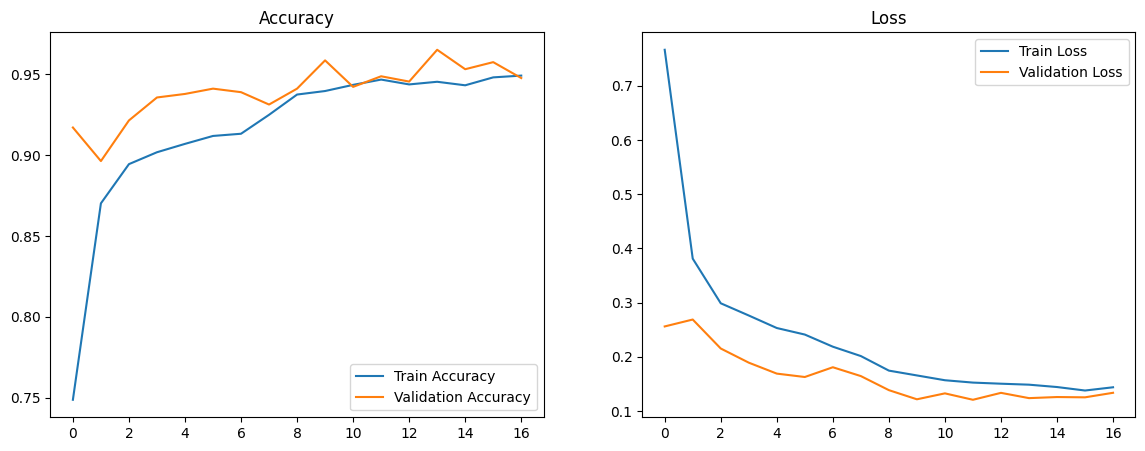

In [1]:
# =========================================================
# AI SMART CANTEEN - ADVANCED TRAINING VERSION
# =========================================================

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

import matplotlib.pyplot as plt
import numpy as np
import json
import os

print("TensorFlow version:", tf.__version__)

# =========================================================
# 1. CONNECT GOOGLE DRIVE
# =========================================================
from google.colab import drive
drive.mount('/content/drive')

# =========================================================
# 2. DATASET PATH
# =========================================================
dataset_path = "/content/drive/MyDrive/datadoan"

# =========================================================
# 3. SETTINGS
# =========================================================
IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 40

# =========================================================
# 4. DATA AUGMENTATION
# =========================================================
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,

    rotation_range=25,
    zoom_range=0.25,
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=0.15,

    horizontal_flip=True,
    brightness_range=[0.8, 1.2],

    fill_mode='nearest'
)

# =========================================================
# 5. LOAD TRAIN DATA
# =========================================================
train_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

# =========================================================
# 6. LOAD VALIDATION DATA
# =========================================================
val_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

# =========================================================
# 7. CLASS NAMES
# =========================================================
class_names = list(train_generator.class_indices.keys())

print("\nClasses:")
for i, name in enumerate(class_names):
    print(i, ":", name)

# Save class names
with open("class_names.json", "w") as f:
    json.dump(class_names, f)

# =========================================================
# 8. LOAD PRETRAINED MODEL
# =========================================================
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

# Freeze base model
base_model.trainable = False

# =========================================================
# 9. BUILD MODEL
# =========================================================
model = models.Sequential([

    base_model,

    layers.GlobalAveragePooling2D(),

    layers.Dropout(0.3),

    layers.Dense(256, activation='relu'),

    layers.Dropout(0.3),

    layers.Dense(len(class_names), activation='softmax')
])

# =========================================================
# 10. COMPILE MODEL
# =========================================================
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# =========================================================
# 11. CALLBACKS
# =========================================================
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=2,
    min_lr=1e-6
)

checkpoint = ModelCheckpoint(
    "best_model.keras",
    monitor='val_accuracy',
    save_best_only=True
)

# =========================================================
# 12. MODEL SUMMARY
# =========================================================
model.summary()

# =========================================================
# 13. TRAIN MODEL
# =========================================================
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    callbacks=[
        early_stop,
        reduce_lr,
        checkpoint
    ]
)

# =========================================================
# 14. SAVE MODEL
# =========================================================
model.save("ainhandiendoan.h5")

print("\n✅ Model saved!")

# =========================================================
# 15. PLOT RESULT
# =========================================================
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(len(acc))

plt.figure(figsize=(14,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(epochs_range, acc, label='Train Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Accuracy')

# Loss
plt.subplot(1,2,2)
plt.plot(epochs_range, loss, label='Train Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Loss')

plt.show()